In [162]:
# Import our standard libraries.
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns  # for nicer plots
sns.set(style='darkgrid')  # default style
import tensorflow as tf

In [163]:
# Load a generic delimited text file
df = pd.read_csv('DS0001/39657-0001-Data.tsv', sep='\t')
df.head()
my_list = df.columns.tolist()
print(my_list)

['YEAR', 'STATEID', 'STATE', 'REGION', 'CUSGT1M', 'CUSGT1F', 'CUSLT1M', 'CUSLT1F', 'CUSUNSM', 'CUSUNSF', 'CUSTOTM', 'CUSTOTF', 'CUSGT1T', 'CUSLT1T', 'CUSUNST', 'CUSTOTT', 'CNOPRIVM', 'CNOPRIVF', 'CWPRIVM', 'CWPRIVF', 'JURGT1M', 'JURGT1F', 'JURLT1M', 'JURLT1F', 'JURUNSM', 'JURUNSF', 'JURTOTM', 'JURTOTF', 'PVINM', 'PVINF', 'PVOTHM', 'PVOTHF', 'PVINCLM', 'PVINCLF', 'LFM', 'LFF', 'LFINCLM', 'LFINCLF', 'LFCROWDM', 'LFCROWDF', 'LFCRSTM', 'LFCRSTF', 'LFCRINCM', 'LFCRINCF', 'FEDM', 'FEDF', 'OTHSTM', 'OTHSTF', 'FACINCLM', 'FACINCLF', 'FACROWDM', 'FACROWDF', 'WHITEM', 'WHITEF', 'BLACKM', 'BLACKF', 'HISPM', 'HISPF', 'AIANM', 'AIANF', 'ASIANM', 'ASIANF', 'NHPIM', 'NHPIF', 'APIM', 'APIF', 'TWORACEM', 'TWORACEF', 'ADDRACEM', 'ADDRACEF', 'UNKRACEM', 'UNKRACEF', 'TOTRACEM', 'TOTRACEF', 'NOTHISPM', 'NOTHISPF', 'UNKHISPM', 'UNKHISPF', 'TOTHCATM', 'TOTHCATF', 'COMMITM', 'COMMITF', 'PARNEWM', 'PARNEWF', 'PARNOM', 'PARNOF', 'ADCRNEWM', 'ADCRNEWF', 'ADCRNOM', 'ADCRNOF', 'ADTRANSM', 'ADTRANSF', 'ADAWOLM', 'A

In [164]:
## Renaming
import pandas as pd

# Define the new column names mapping
column_mapping = {
    'YEAR': 'year',
    'STATEID': 'state_id',
    'STATE': 'state_name',
    'REGION': 'region',
    
    # Custody population (physical in facility)
    'CUSGT1M': 'custody_gt1yr_male',
    'CUSGT1F': 'custody_gt1yr_female',
    'CUSLT1M': 'custody_lt1yr_male',
    'CUSLT1F': 'custody_lt1yr_female',
    'CUSUNSM': 'custody_unsentenced_male',
    'CUSUNSF': 'custody_unsentenced_female',
    'CUSTOTM': 'custody_total_male',
    'CUSTOTF': 'custody_total_female',
    'CUSGT1T': 'custody_gt1yr_total',
    'CUSLT1T': 'custody_lt1yr_total',
    'CUSUNST': 'custody_unsentenced_total',
    'CUSTOTT': 'custody_total_all',
    
    # Facility type (private vs non-private)
    'CNOPRIVM': 'custody_nonprivate_male',
    'CNOPRIVF': 'custody_nonprivate_female',
    'CWPRIVM': 'custody_private_male',
    'CWPRIVF': 'custody_private_female',
    
    # Jurisdiction population (legal authority)
    'JURGT1M': 'jurisdiction_gt1yr_male',
    'JURGT1F': 'jurisdiction_gt1yr_female',
    'JURLT1M': 'jurisdiction_lt1yr_male',
    'JURLT1F': 'jurisdiction_lt1yr_female',
    'JURUNSM': 'jurisdiction_unsentenced_male',
    'JURUNSF': 'jurisdiction_unsentenced_female',
    'JURTOTM': 'jurisdiction_total_male',
    'JURTOTF': 'jurisdiction_total_female',
    
    # Private facility counts
    'PVINM': 'private_in_state_male',
    'PVINF': 'private_in_state_female',
    'PVOTHM': 'private_out_state_male',
    'PVOTHF': 'private_out_state_female',
    'PVINCLM': 'private_included_male',
    'PVINCLF': 'private_included_female',
    
    # Facility security levels
    'LFM': 'level1_male',
    'LFF': 'level1_female',
    'LFINCLM': 'level1_included_male',
    'LFINCLF': 'level1_included_female',
    'LFCROWDM': 'level1_crowded_male',
    'LFCROWDF': 'level1_crowded_female',
    'LFCRSTM': 'level1_restricted_male',
    'LFCRSTF': 'level1_restricted_female',
    'LFCRINCM': 'level1_restricted_inc_male',
    'LFCRINCF': 'level1_restricted_inc_female',
    
    # Federal and other state facilities
    'FEDM': 'federal_male',
    'FEDF': 'federal_female',
    'OTHSTM': 'other_state_male',
    'OTHSTF': 'other_state_female',
    'FACINCLM': 'facility_included_male',
    'FACINCLF': 'facility_included_female',
    'FACROWDM': 'facility_crowded_male',
    'FACROWDF': 'facility_crowded_female',
    
    # Race categories
    'WHITEM': 'white_male',
    'WHITEF': 'white_female',
    'BLACKM': 'black_male',
    'BLACKF': 'black_female',
    'HISPM': 'hispanic_male',
    'HISPF': 'hispanic_female',
    'AIANM': 'native_american_male',
    'AIANF': 'native_american_female',
    'ASIANM': 'asian_male',
    'ASIANF': 'asian_female',
    'NHPIM': 'pacific_islander_male',
    'NHPIF': 'pacific_islander_female',
    'APIM': 'asian_pacific_islander_male',
    'APIF': 'asian_pacific_islander_female',
    'TWORACEM': 'two_or_more_races_male',
    'TWORACEF': 'two_or_more_races_female',
    'ADDRACEM': 'additional_races_male',
    'ADDRACEF': 'additional_races_female',
    'UNKRACEM': 'unknown_race_male',
    'UNKRACEF': 'unknown_race_female',
    'TOTRACEM': 'total_race_male',
    'TOTRACEF': 'total_race_female',
    
    # Ethnicity (Hispanic origin)
    'NOTHISPM': 'not_hispanic_male',
    'NOTHISPF': 'not_hispanic_female',
    'UNKHISPM': 'unknown_hispanic_male',
    'UNKHISPF': 'unknown_hispanic_female',
    'TOTHCATM': 'total_hispanic_categories_male',
    'TOTHCATF': 'total_hispanic_categories_female',
    
    # Admissions
    'COMMITM': 'admissions_new_court_male',
    'COMMITF': 'admissions_new_court_female',
    'PARNEWM': 'admissions_parole_new_sentence_male',
    'PARNEWF': 'admissions_parole_new_sentence_female',
    'PARNOM': 'admissions_parole_no_sentence_male',
    'PARNOF': 'admissions_parole_no_sentence_female',
    'ADCRNEWM': 'admissions_court_new_male',
    'ADCRNEWF': 'admissions_court_new_female',
    'ADCRNOM': 'admissions_court_no_sentence_male',
    'ADCRNOF': 'admissions_court_no_sentence_female',
    'ADTRANSM': 'admissions_transfers_male',
    'ADTRANSF': 'admissions_transfers_female',
    'ADAWOLM': 'admissions_awol_returned_male',
    'ADAWOLF': 'admissions_awol_returned_female',
    'ADESCAPM': 'admissions_escapee_returned_male',
    'ADESCAPF': 'admissions_escapee_returned_female',
    'ADAWESM': 'admissions_awol_escape_male',
    'ADAWESF': 'admissions_awol_escape_female',
    'ADRETM': 'admissions_returns_male',
    'ADRETF': 'admissions_returns_female',
    'ADOTHM': 'admissions_other_male',
    'ADOTHF': 'admissions_other_female',
    'ADTOTM': 'admissions_total_male',
    'ADTOTF': 'admissions_total_female',
    
    # Releases
    'RLUNEXPM': 'releases_unexpired_male',
    'RLUNEXPF': 'releases_unexpired_female',
    'RLUNCOMM': 'releases_unconditional_male',
    'RLUNCOMF': 'releases_unconditional_female',
    'RLUNOTHM': 'releases_unconditional_other_male',
    'RLUNOTHF': 'releases_unconditional_other_female',
    'RLCOPROM': 'releases_conditional_probation_male',
    'RLCOPROF': 'releases_conditional_probation_female',
    'RLCOSUPM': 'releases_conditional_supervised_male',
    'RLCOSUPF': 'releases_conditional_supervised_female',
    'RLCODPM': 'releases_conditional_discretionary_male',
    'RLCODPF': 'releases_conditional_discretionary_female',
    'RLCOOTHM': 'releases_conditional_other_male',
    'RLCOOTHF': 'releases_conditional_other_female',
    'RLDEATHM': 'releases_death_male',
    'RLDEATHF': 'releases_death_female',
    'RLAWOLM': 'releases_awol_male',
    'RLAWOLF': 'releases_awol_female',
    'RLESCAPM': 'releases_escape_male',
    'RLESCAPF': 'releases_escape_female',
    'RLAWESM': 'releases_awol_escape_male',
    'RLAWESF': 'releases_awol_escape_female',
    'RLTRANM': 'releases_transfers_male',
    'RLTRANF': 'releases_transfers_female',
    'RLBONDM': 'releases_bond_male',
    'RLBONDF': 'releases_bond_female',
    'RLOTHM': 'releases_other_male',
    'RLOTHF': 'releases_other_female',
    'RLTOTM': 'releases_total_male',
    'RLTOTF': 'releases_total_female',
    
    # Flow counts (January/December)
    'FLOJANM': 'flow_january_male',
    'FLOJANF': 'flow_january_female',
    'FLOADMM': 'flow_admissions_male',
    'FLOADMF': 'flow_admissions_female',
    'FLORLM': 'flow_releases_male',
    'FLORLF': 'flow_releases_female',
    'FLODECM': 'flow_december_male',
    'FLODECF': 'flow_december_female',
    
    # Capital punishment
    'CAPRATEM': 'capital_rate_male',
    'CAPRATEF': 'capital_rate_female',
    'CAPOPM': 'capital_population_male',
    'CAPOPF': 'capital_population_female',
    'CAPDESM': 'capital_death_sentences_male',
    'CAPDESF': 'capital_death_sentences_female',
    'CAPRATET': 'capital_rate_total',
    'CAPOPT': 'capital_population_total',
    'CAPDEST': 'capital_death_sentences_total',
    
    # HIV/AIDS variables
    'HIVTEST': 'hiv_tested',
    'HIVINC': 'hiv_incarcerated',
    'HIVCUR': 'hiv_current_cases',
    'HIVREL': 'hiv_released',
    'HIVRAN': 'hiv_random_testing',
    'HIVCERT': 'hiv_certified',
    'HIVHIGH': 'hiv_high_risk',
    'HIVREQ': 'hiv_required_testing',
    'HIVORD': 'hiv_court_ordered',
    'HIVCLIN': 'hiv_clinic_testing',
    'HIVINCID': 'hiv_incident_cases',
    'HIVOTH': 'hiv_other_policies',
    'HIVNOCUS': 'hiv_no_custody',
    'HIVCUSME': 'hiv_custody_measures',
    'ADHIVTST': 'admissions_hiv_tested',
    'CONSTYPE': 'facility_construction_type',
    'HIVEXTST': 'hiv_extended_testing',
    'HIVASYMM': 'hiv_asymptomatic_male',
    'HIVASYMF': 'hiv_asymptomatic_female',
    'HIVASYMT': 'hiv_asymptomatic_total',
    'HIVLESSM': 'hiv_less_than_male',
    'HIVLESSF': 'hiv_less_than_female',
    'HIVLESST': 'hiv_less_than_total',
    'AIDSCONM': 'aids_confirmed_male',
    'AIDSCONF': 'aids_confirmed_female',
    'AIDSCONT': 'aids_confirmed_total',
    'HIVATOTM': 'hiv_aids_total_male',
    'IMP_HIVTOTM': 'imputed_hiv_total_male',
    'HIVATOTF': 'hiv_aids_total_female',
    'IMP_HIVTOTF': 'imputed_hiv_total_female',
    'HIVATOTT': 'hiv_aids_total_all',
    'IMP_HIVATOTT': 'imputed_hiv_aids_total',
    'RV_HIVATOTT': 'revised_hiv_aids_total',
    
    # Custody under 18 and citizenship
    'CUSLT18M': 'custody_under18_male',
    'CUSLT18F': 'custody_under18_female',
    'CUSCTZNM': 'custody_citizen_male',
    'CUSCTZNF': 'custody_citizen_female',
    'CITZTOT': 'citizen_total',
    'NCITZTOT': 'non_citizen_total',
    'UNCITZTOTM': 'unknown_citizen_total_male',
    'UNCITZTOTF': 'unknown_citizen_total_female',
    'UNKCITZTOT': 'unknown_citizen_total',
    'CITZTOTM': 'citizen_total_male',
    'CITZTOTF': 'citizen_total_female',
    'CITZGT1M': 'citizen_gt1yr_male',
    'CITZGT1F': 'citizen_gt1yr_female',
    'CITZLE1M': 'citizen_lt1yr_male',
    'CITZLE1F': 'citizen_lt1yr_female',
    'CITZUNSM': 'citizen_unsentenced_male',
    'CITZUNSF': 'citizen_unsentenced_female',
    'NCITZTOTM': 'non_citizen_total_male',
    'NCITZTOTF': 'non_citizen_total_female',
    'NCITZGT1M': 'non_citizen_gt1yr_male',
    'NCITZGT1F': 'non_citizen_gt1yr_female',
    'NCITZLE1M': 'non_citizen_lt1yr_male',
    'NCITZLE1F': 'non_citizen_lt1yr_female',
    'NCITZUNSM': 'non_citizen_unsentenced_male',
    'NCITZUNSF': 'non_citizen_unsentenced_female',
    'NCITZSELF': 'non_citizen_self_reported',
    'NCITZDOCS': 'non_citizen_documented',
    'NCITZVERIF': 'non_citizen_verified',
    'CITZPOP': 'citizen_population',
    
    # Deaths while incarcerated
    'DTHEXECM': 'deaths_executions_male',
    'DTHEXECF': 'deaths_executions_female',
    'DTHILLNM': 'deaths_illness_male',
    'DTHILLNF': 'deaths_illness_female',
    'DTHAIDSM': 'deaths_aids_male',
    'DTHAIDSF': 'deaths_aids_female',
    'DTHSUICM': 'deaths_suicide_male',
    'DTHSUICF': 'deaths_suicide_female',
    'DTHACCM': 'deaths_accident_male',
    'DTHACCF': 'deaths_accident_female',
    'DTHHOMIM': 'deaths_homicide_inmate_male',
    'DTHHOMIF': 'deaths_homicide_inmate_female',
    'DTHHOMOM': 'deaths_homicide_other_male',
    'DTHHOMOF': 'deaths_homicide_other_female',
    'DTHPERSM': 'deaths_personal_male',
    'DTHPERSF': 'deaths_personal_female',
    'DTHOTHM': 'deaths_other_male',
    'DTHOTHF': 'deaths_other_female',
    'DTHTOTM': 'deaths_total_male',
    'DTHTOTF': 'deaths_total_female',
    
    # Handle/identifier
    'HANDLEM': 'handle_male',
    'HANDLEF': 'handle_female'
}

def rename_columns(df):
    """
    Rename prison dataset columns to more readable names.
    
    Parameters:
    df (pandas.DataFrame): DataFrame with original column names
    
    Returns:
    pandas.DataFrame: DataFrame with renamed columns
    """
    # Only rename columns that exist in the DataFrame
    existing_mapping = {old: new for old, new in column_mapping.items() if old in df.columns}
    
    # Rename the columns
    df_renamed = df.rename(columns=existing_mapping)
    
    return df_renamed

# Example usage:
# Load your dataset
# df = pd.read_csv('prison_data.csv')


In [165]:
# Rename columns

df_renamed = rename_columns(df)
# Print the new column names
print(df_renamed.columns.tolist())
print("\n📊 Records per year:")
print(df_renamed['year'].value_counts().sort_index())

['year', 'state_id', 'state_name', 'region', 'custody_gt1yr_male', 'custody_gt1yr_female', 'custody_lt1yr_male', 'custody_lt1yr_female', 'custody_unsentenced_male', 'custody_unsentenced_female', 'custody_total_male', 'custody_total_female', 'custody_gt1yr_total', 'custody_lt1yr_total', 'custody_unsentenced_total', 'custody_total_all', 'custody_nonprivate_male', 'custody_nonprivate_female', 'custody_private_male', 'custody_private_female', 'jurisdiction_gt1yr_male', 'jurisdiction_gt1yr_female', 'jurisdiction_lt1yr_male', 'jurisdiction_lt1yr_female', 'jurisdiction_unsentenced_male', 'jurisdiction_unsentenced_female', 'jurisdiction_total_male', 'jurisdiction_total_female', 'private_in_state_male', 'private_in_state_female', 'private_out_state_male', 'private_out_state_female', 'private_included_male', 'private_included_female', 'level1_male', 'level1_female', 'level1_included_male', 'level1_included_female', 'level1_crowded_male', 'level1_crowded_female', 'level1_restricted_male', 'level1

In [166]:
df_renamed['jurisdiction_total_all'] = (
    df_renamed['jurisdiction_total_male'] + 
    df_renamed['jurisdiction_total_female']
)
df_final_columns = df_renamed[['year', 'state_id', 'state_name', 'region',  'jurisdiction_total_all']]


print(df_final_columns.head())
print("Min year:", df_final_columns['year'].min())
print("Max year:", df_final_columns['year'].max())

   year  state_id state_name  region  jurisdiction_total_all
0  1978         1         AL       3                    5625
1  1979         1         AL       3                    5464
2  1980         1         AL       3                    6543
3  1981         1         AL       3                    7657
4  1982         1         AL       3                    9233
Min year: 1978
Max year: 2023


/var/folders/lg/tfc2hbss2lj5n9gvw2wq701w0000gn/T/ipykernel_76458/3168009358.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_renamed['jurisdiction_total_all'] = (


Missing Values in the total fields?

In [167]:
# Define your missing value placeholders
missing_values = [-1, -999, 999, 0, '', 'NaN', -8]  # add whatever you consider "missing"

count = (df_final_columns['jurisdiction_total_all'] == "<NA>").sum()
print(count)


# Count all occurrences of these values plus NaN
count = df_final_columns['jurisdiction_total_all'].isin(missing_values).sum() + df_final_columns['jurisdiction_total_all'].isna().sum()
print(f"Total missing values: {count}", "total over all:", len(df_final_columns))

0
Total missing values: 0 total over all: 2484


Aggreagate by years over all   

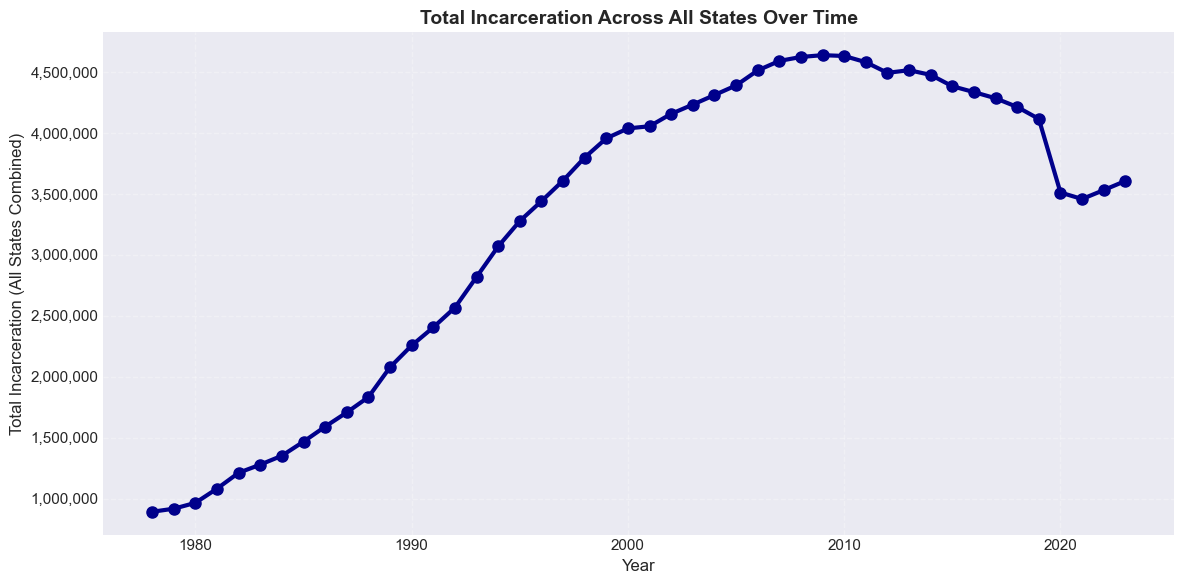

Yearly totals:
    year  jurisdiction_total_all
0   1978                  892025
1   1979                  917000
2   1980                  965100
3   1981                 1081657
4   1982                 1211745
5   1983                 1278639
6   1984                 1351743
7   1985                 1467298
8   1986                 1590508
9   1987                 1706952
10  1988                 1832872
11  1989                 2077921
12  1990                 2256231
13  1991                 2405069
14  1992                 2567241
15  1993                 2818316
16  1994                 3069072
17  1995                 3277372
18  1996                 3440213
19  1997                 3609004
20  1998                 3798421
21  1999                 3955812
22  2000                 4037277
23  2001                 4055087
24  2002                 4156888
25  2003                 4232728
26  2004                 4310956
27  2005                 4390096
28  2006                 451

In [186]:
# Calculate total across all states for each year
yearly_total = df_final_columns.groupby('year')['jurisdiction_total_all'].sum().reset_index()

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(yearly_total['year'], yearly_total['jurisdiction_total_all'], 
         marker='o', linewidth=3, markersize=8, color='darkblue')

# Add labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Incarceration (All States Combined)', fontsize=12)
plt.title('Total Incarceration Across All States Over Time', fontsize=14, fontweight='bold')

# Add grid
plt.grid(True, alpha=0.3, linestyle='--')

# Format y-axis with commas for thousands
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))



plt.tight_layout()
plt.show()

# Print the totals
print("Yearly totals:")
print(yearly_total)


Incareceration over time in the US

/var/folders/lg/tfc2hbss2lj5n9gvw2wq701w0000gn/T/ipykernel_76458/1585520682.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


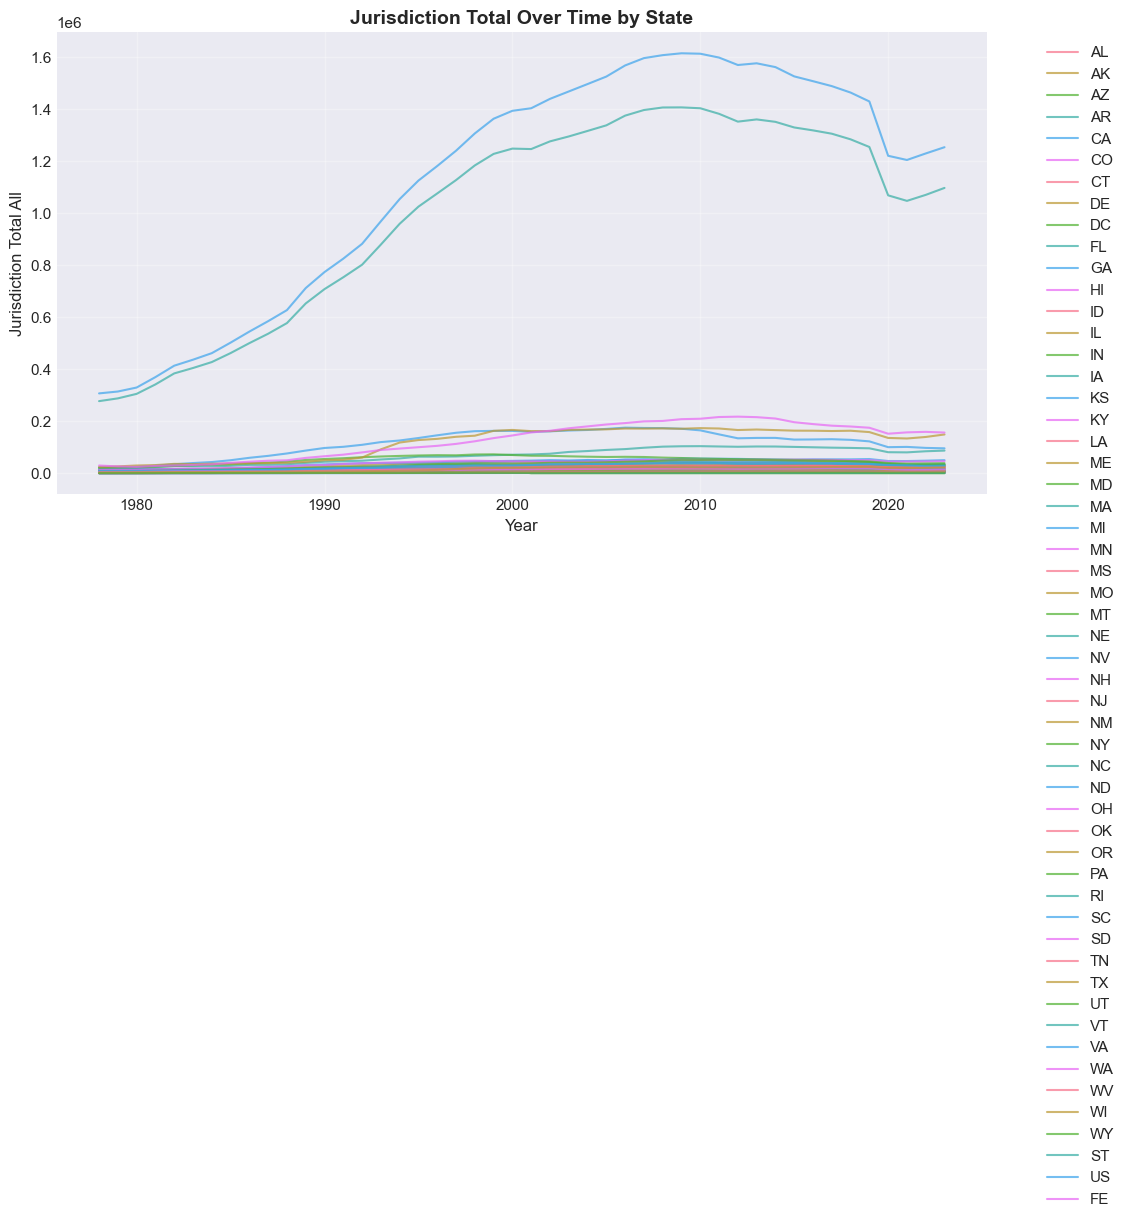

In [175]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure
plt.figure(figsize=(12, 6))

# Line plot for each state
for state in df_final_columns['state_name'].unique():
    state_data = df_final_columns[df_final_columns['state_name'] == state]
    plt.plot(state_data['year'], state_data['jurisdiction_total_all'], 
             label=state, linewidth=1.5, alpha=0.7)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Jurisdiction Total All', fontsize=12)
plt.title('Jurisdiction Total Over Time by State', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

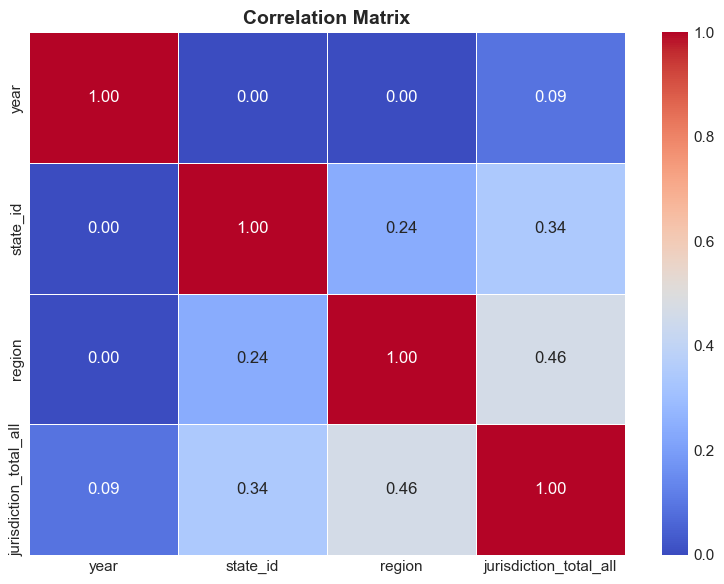

In [177]:
numeric_cols = df_final_columns.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Cities and Years to care about

Summer Olympics
- Los Angeles ( 1984)
- Atlanta (1996)

Winter Olympics
- Lake Placid ( 1980)
- Salt Lake City (2002)

I'd say we only care about the 2 years before and 3 years after. So a 6 year span.
- 1960, 1984, 1996, 1960, 2002


years_of_interest = 
                     1982, 1983, 1984, 1985, 1986, 1987,  # Los Angeles
                     1994, 1995, 1996, 1997, 1998, 1999,  # Atlanta
                     2000, 2001, 2002, 2003, 2004, 2005, # Utah
                     1978, 1979, 1980, 1881, 1982, 1983]  # New York

states_of_interest = [, 'California', 'Georgia', 'Utah', 'New York']  # Add or change as needed

In [169]:
# Group by state and year with total custody count
state_year_totals = df_final_columns.groupby(['state_name', 'year'])['jurisdiction_total_all'].sum().reset_index()

print("\n" + "="*80)
print("TOTAL CUSTODY POPULATION BY STATE AND YEAR")
print("="*80)
print(state_year_totals)




TOTAL CUSTODY POPULATION BY STATE AND YEAR
     state_name  year  jurisdiction_total_all
0            AK  1978                     712
1            AK  1979                     760
2            AK  1980                     822
3            AK  1981                    1024
4            AK  1982                    1322
...         ...   ...                     ...
2479         WY  2019                    2479
2480         WY  2020                    2087
2481         WY  2021                    2123
2482         WY  2022                    2154
2483         WY  2023                    2212

[2484 rows x 3 columns]


In [187]:

years_of_interest = [1982, 1983, 1984, 1985, 1986, 1987,  # Los  /CA
                     1994, 1995, 1996, 1997, 1998, 1999,  # Atlanta / GA
                     2000, 2001, 2002, 2003, 2004, 2005,  # Utah 
                     1978, 1979, 1980, 1881, 1982, 1983]  # New York

states_of_interest = [ 'CA', 'GA', 'UT', 'NY']  # Add or change as needed

# Define Olympics events with labels
olympic_events = {
    1984: {'label': 'LA 1984', 'type': 'Summer', 'color': 'red'},
    1996: {'label': 'Atlanta 1996', 'type': 'Summer', 'color': 'red'},
    1980: {'label': 'Lake Placid 1980', 'type': 'Winter', 'color': 'blue'},
    2002: {'label': 'Salt Lake City 2002', 'type': 'Winter', 'color': 'blue'}
}

filtered_df = df_final_columns[
    df_final_columns['state_name'].isin(states_of_interest)  
    # df_final_columns['year'].isin(years_of_interest)
]

filtered_df


,year,state_id,state_name,region,jurisdiction_total_all,region_label
184,1978,6,CA,4,21325,4
185,1979,6,CA,4,22632,4
186,1980,6,CA,4,24569,4
187,1981,6,CA,4,29202,4
188,1982,6,CA,4,34640,4
...,...,...,...,...,...,...
2065,2019,49,UT,4,6671,4
2066,2020,49,UT,4,5448,4
2067,2021,49,UT,4,5911,4
2068,2022,49,UT,4,6009,4


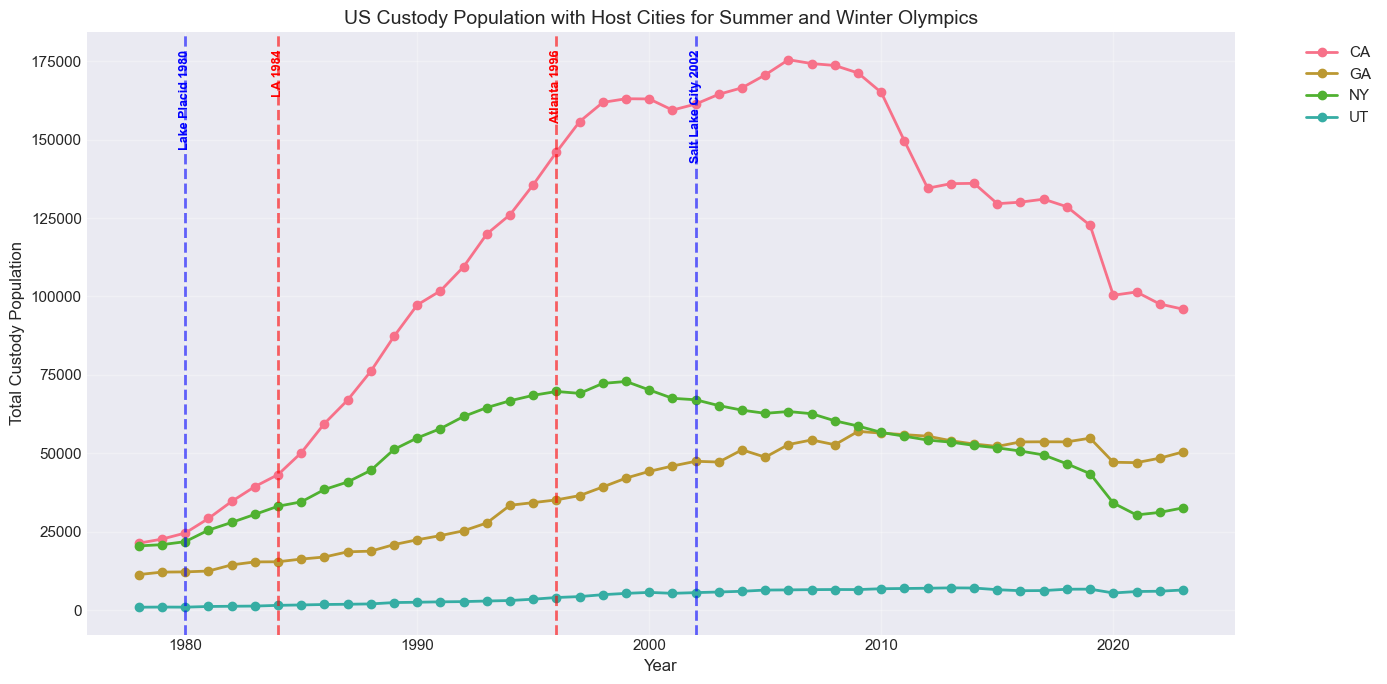

In [188]:

# Plot with vertical lines
plt.figure(figsize=(14, 7))

for state in filtered_df['state_name'].unique():
    state_data = filtered_df[filtered_df['state_name'] == state]
    plt.plot(state_data['year'], state_data['jurisdiction_total_all'], 
             marker='o', label=state, linewidth=2)

# Add vertical lines for Olympics
max_y = plt.ylim()[1]
for year, info in olympic_events.items():
    if year in filtered_df['year'].values:
        plt.axvline(x=year, color=info['color'], linestyle='--', alpha=0.6, linewidth=2)
        plt.text(year, max_y * 0.97, info['label'], 
                 rotation=90, verticalalignment='top', 
                 horizontalalignment='center',
                 fontsize=9, color=info['color'], fontweight='bold')

plt.title('US Custody Population with Host Cities for Summer and Winter Olympics', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Custody Population', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

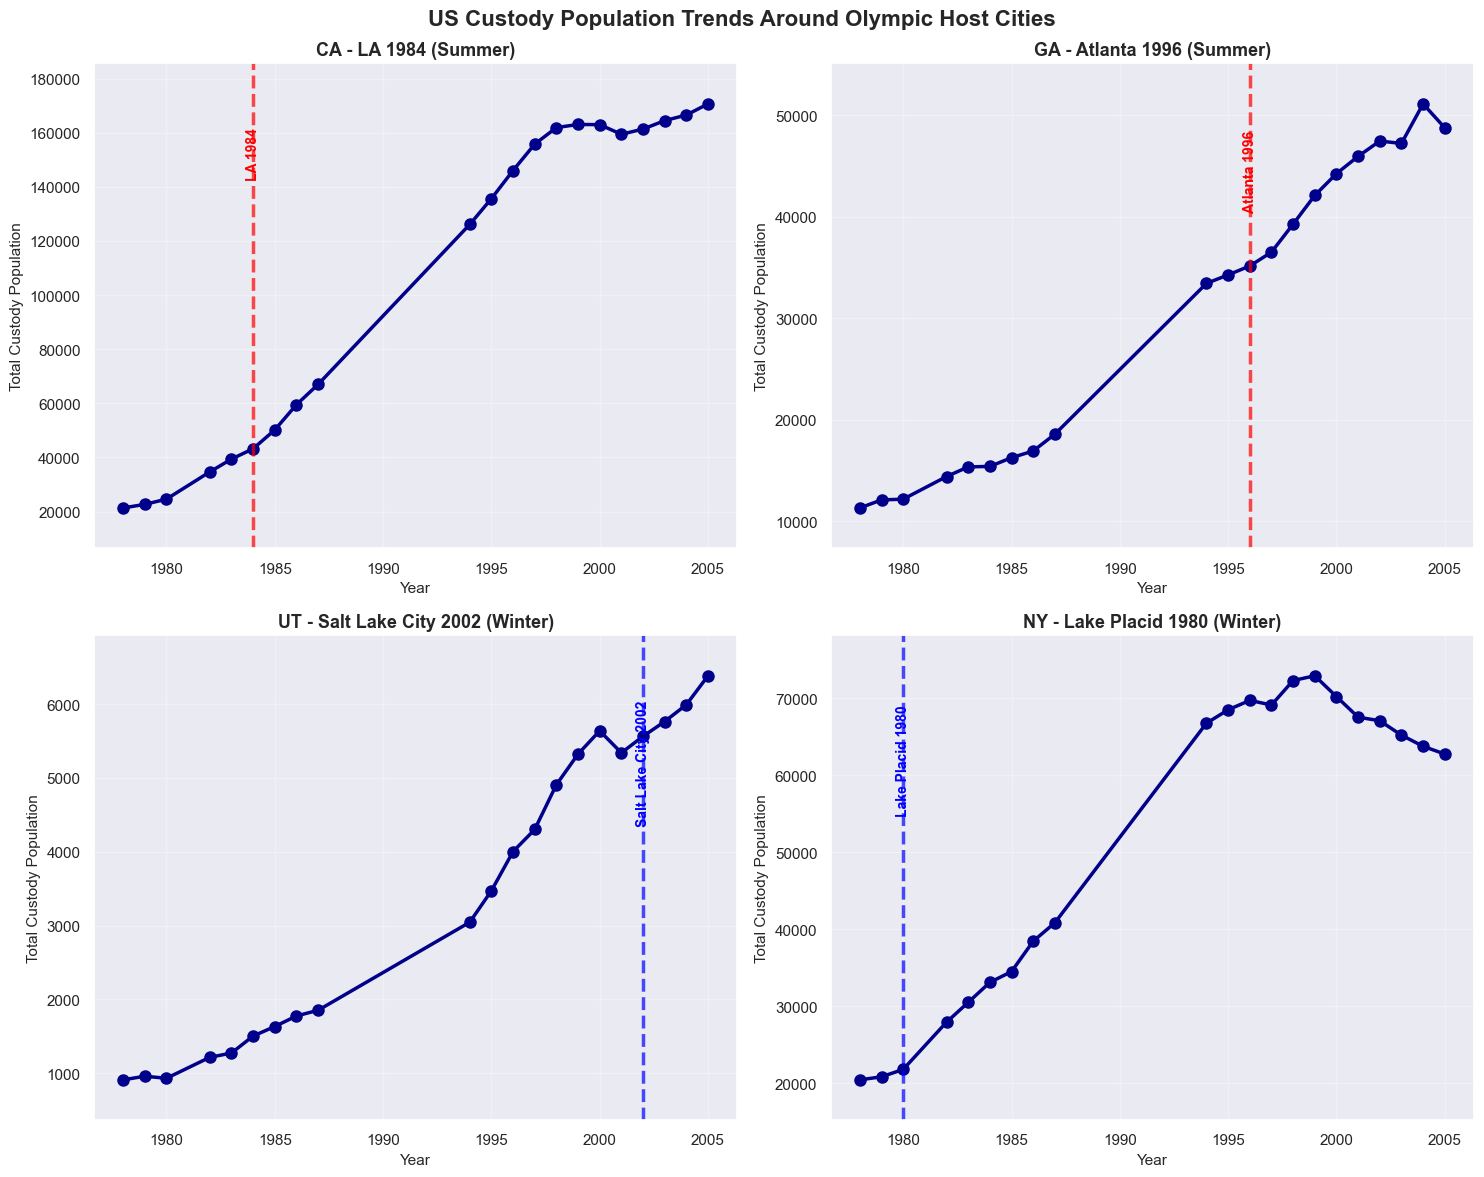

In [174]:
import matplotlib.pyplot as plt
import numpy as np

# Define the data for each state with their respective Olympic events
# For each state, we'll show the years around their specific event

# State-event mapping
state_event_mapping = {
    'CA': {'event_year': 1984, 'event_label': 'LA 1984', 'event_type': 'Summer'},
    'GA': {'event_year': 1996, 'event_label': 'Atlanta 1996', 'event_type': 'Summer'},
    'UT': {'event_year': 2002, 'event_label': 'Salt Lake City 2002', 'event_type': 'Winter'},
    'NY': {'event_year': 1980, 'event_label': 'Lake Placid 1980', 'event_type': 'Winter'}
}

# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Colors for event types
event_colors = {'Summer': 'red', 'Winter': 'blue'}

# Plot each state separately
for idx, (state, event_info) in enumerate(state_event_mapping.items()):
    # Filter data for this state
    state_data = filtered_df[filtered_df['state_name'] == state]
    
    # Sort by year
    state_data = state_data.sort_values('year')
    
    # Plot on the appropriate subplot
    ax = axes[idx]
    ax.plot(state_data['year'], state_data['jurisdiction_total_all'], 
            marker='o', linewidth=2.5, color='darkblue', markersize=8)
    
    # Highlight the Olympic year
    event_year = event_info['event_year']
    event_label = event_info['event_label']
    event_type = event_info['event_type']
    color = event_colors[event_type]
    
    # Add vertical line for Olympic year
    if event_year in state_data['year'].values:
        ax.axvline(x=event_year, color=color, linestyle='--', alpha=0.7, linewidth=2.5)
        
        # Add text annotation for the event
        max_y = state_data['jurisdiction_total_all'].max()
        ax.text(event_year, max_y * 0.95, event_label, 
                rotation=90, verticalalignment='top', 
                horizontalalignment='center',
                fontsize=10, color=color, fontweight='bold')
    
    # Add title with state and event info
    ax.set_title(f'{state} - {event_label} ({event_type})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Total Custody Population', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Set x-axis ticks to show all years
    # ax.set_xticks(state_data['year'].values)
    
    # Add some padding to y-axis
    y_min = state_data['jurisdiction_total_all'].min()
    y_max = state_data['jurisdiction_total_all'].max()
    y_range = y_max - y_min
    ax.set_ylim(y_min - y_range * 0.1, y_max + y_range * 0.1)

# Adjust layout
plt.suptitle('US Custody Population Trends Around Olympic Host Cities', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# # Alternative: Create a single plot with subplots showing only the 3 years before and after each event
# fig2, axes2 = plt.subplots(2, 2, figsize=(15, 12))
# axes2 = axes2.flatten()

# for idx, (state, event_info) in enumerate(state_event_mapping.items()):
#     event_year = event_info['event_year']
#     event_label = event_info['event_label']
#     event_type = event_info['event_type']
#     color = event_colors[event_type]
    
#     # Filter for 3 years before and after the event
#     year_range = range(event_year - 3, event_year + 4)
#     state_data = filtered_df[(filtered_df['state_name'] == state) & 
#                              (filtered_df['year'].isin(year_range))]
#     state_data = state_data.sort_values('year')
    
#     ax = axes2[idx]
    
#     # Plot with different colors for before, during, and after
#     before_data = state_data[state_data['year'] < event_year]
#     during_data = state_data[state_data['year'] == event_year]
#     after_data = state_data[state_data['year'] > event_year]
    
#     if not before_data.empty:
#         ax.plot(before_data['year'], before_data['jurisdiction_total_all'], 
#                 marker='o', color='gray', linewidth=2, label='Before', linestyle='-')
    
#     if not during_data.empty:
#         ax.plot(during_data['year'], during_data['jurisdiction_total_all'], 
#                 marker='s', color=color, linewidth=3, label='Olympic Year', markersize=10)
    
#     if not after_data.empty:
#         ax.plot(after_data['year'], after_data['jurisdiction_total_all'], 
#                 marker='o', color='green', linewidth=2, label='After', linestyle='-')
    
#     ax.axvline(x=event_year, color=color, linestyle='--', alpha=0.5, linewidth=2)
#     ax.text(event_year, ax.get_ylim()[1] * 0.95, event_label, 
#             rotation=90, verticalalignment='top', 
#             horizontalalignment='center',
#             fontsize=10, color=color, fontweight='bold')
    
#     ax.set_title(f'{state} - {event_label}', fontsize=13, fontweight='bold')
#     ax.set_xlabel('Year', fontsize=11)
#     ax.set_ylabel('Total Custody Population', fontsize=11)
#     ax.grid(True, alpha=0.3)
#     ax.legend(loc='best')
    
#     # Set x-axis ticks
#     ax.set_xticks(sorted(state_data['year'].unique()))

# plt.suptitle('US Custody Population (3 Years Before & After Olympic Events)', 
#              fontsize=16, fontweight='bold', y=0.98)
# plt.tight_layout()
# plt.show()